In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("/content/houseprice.csv")
df.head()

,Living Area,Bathrooms,Bedrooms,Lot Size,Age,Fireplace,Price
0,1.982,1.0,3,2.00,133,0,14.2212
1,1.676,1.5,3,0.38,14,1,13.4865
2,1.694,2.0,3,0.96,15,1,11.8007
3,1.800,1.0,2,0.48,49,1,13.8297
4,2.088,1.0,3,1.84,29,1,12.9470


In [3]:
df.shape

(1047, 7)

In [4]:
df.columns

Index(['Living Area', 'Bathrooms', 'Bedrooms', 'Lot Size', 'Age', 'Fireplace',
       'Price'],
      dtype='object')

In [5]:
df.dtypes

,0
Living Area,float64
Bathrooms,float64
Bedrooms,int64
Lot Size,float64
Age,int64
Fireplace,int64
Price,float64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1047 entries, 0 to 1046
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Living Area  1047 non-null   float64
 1   Bathrooms    1047 non-null   float64
 2   Bedrooms     1047 non-null   int64  
 3   Lot Size     1047 non-null   float64
 4   Age          1047 non-null   int64  
 5   Fireplace    1047 non-null   int64  
 6   Price        1047 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 57.4 KB


In [7]:
df.describe()

,Living Area,Bathrooms,Bedrooms,Lot Size,Age,Fireplace,Price
count,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000
mean,1.807303,1.918338,3.183381,0.569580,28.061127,0.593123,16.386213
std,0.641461,0.641735,0.750265,0.777879,34.900899,0.491486,6.765156
min,0.672000,1.000000,1.000000,0.000000,0.000000,0.000000,1.685800
25%,1.336000,1.500000,3.000000,0.210000,6.000000,0.000000,11.201400
50%,1.672000,2.000000,3.000000,0.390000,18.000000,1.000000,15.191700
75%,2.206000,2.500000,4.000000,0.600000,34.000000,1.000000,20.523500
max,4.534000,4.500000,6.000000,9.000000,247.000000,1.000000,44.643600


In [8]:
df.isnull().sum()

,0
Living Area,0
Bathrooms,0
Bedrooms,0
Lot Size,0
Age,0
Fireplace,0
Price,0


In [9]:
df.duplicated().sum()

np.int64(12)

In [10]:
duplicates = df[df.duplicated()]
print("Duplicate Rows:\n", duplicates)

# Remove duplicates and keep only the first occurrence
df_cleaned = df.drop_duplicates()

# Save the clean data
df_cleaned.to_csv('cleaned_data.csv', index=False)

Duplicate Rows:
       Living Area  Bathrooms  Bedrooms  Lot Size  Age  Fireplace    Price
185         3.355        2.5         4      0.83    1          1  26.3226
188         1.498        1.5         2      0.18    0          1  12.0639
542         2.655        2.5         4      0.37    1          1  21.8184
548         1.184        1.5         2      0.15   18          0   9.8389
566         0.924        1.0         3      0.91   15          0   8.4291
854         1.592        1.5         3      0.16   18          1  12.6082
856         1.673        2.0         2      0.15   18          0  10.4556
859         2.641        3.0         4      0.39    1          1  23.8951
864         2.434        2.5         4      1.00   20          1  23.3876
873         1.540        1.5         3      0.43   16          0  15.5787
882         1.512        2.0         3      0.77   12          1  17.8216
1002        0.912        1.5         2      0.16   20          0   9.5708


In [13]:
df.drop_duplicates(inplace=True)

# Clean data ko new file mein save karne ke liye
df.to_csv('clean_data.csv', index=False)

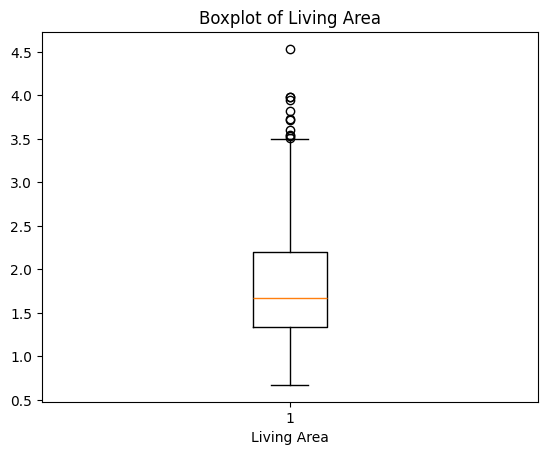

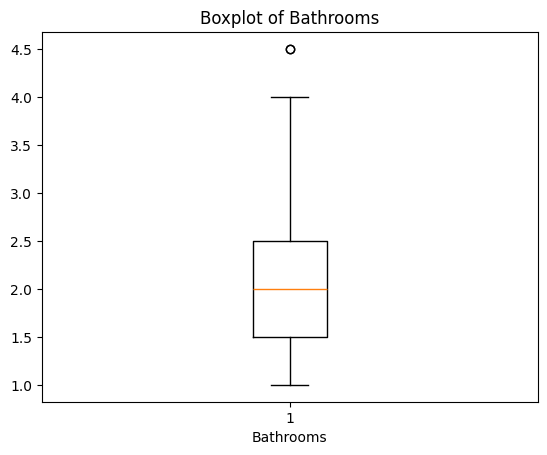

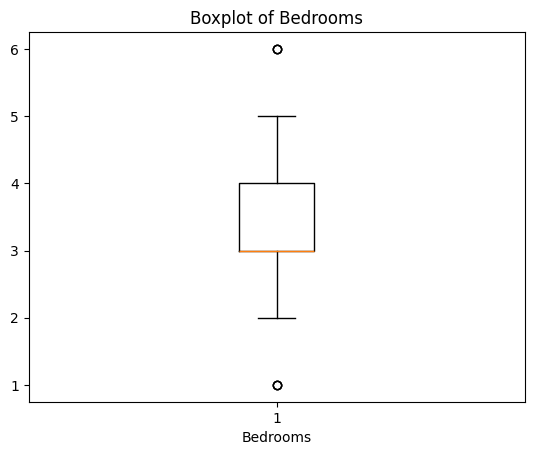

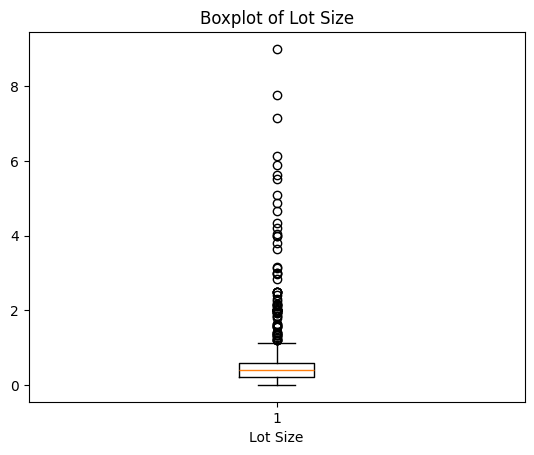

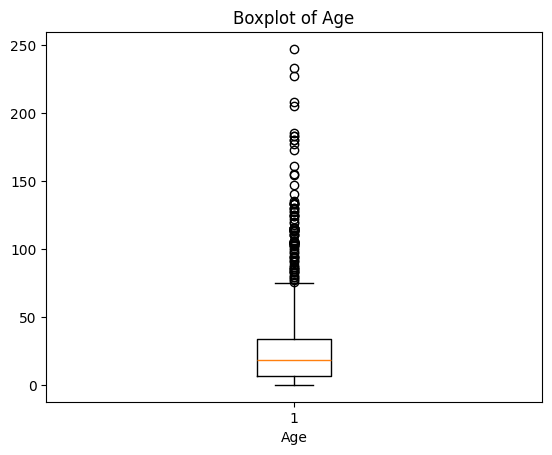

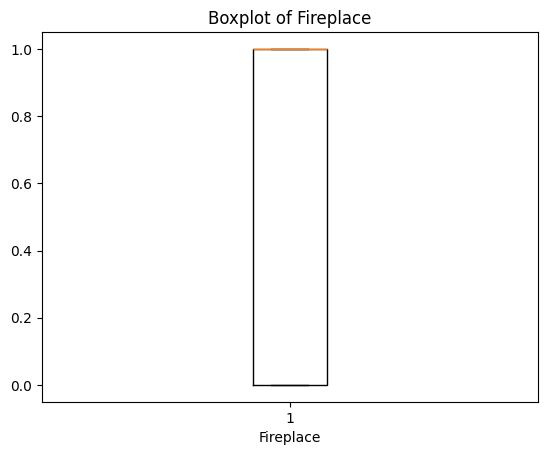

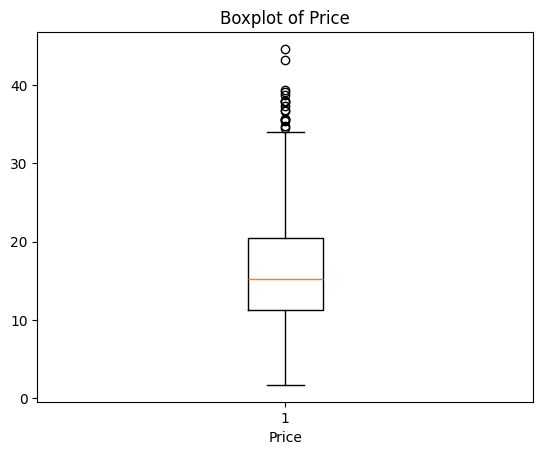

In [16]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [19]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

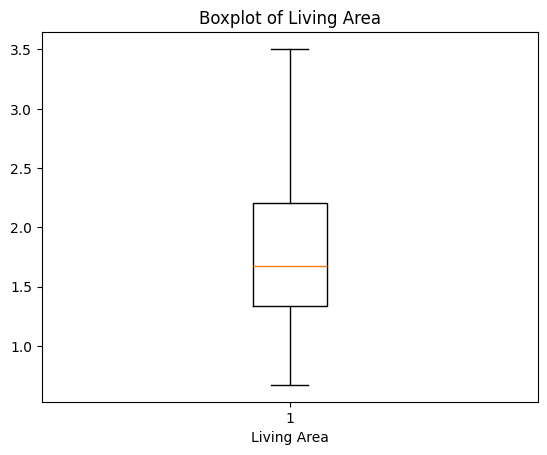

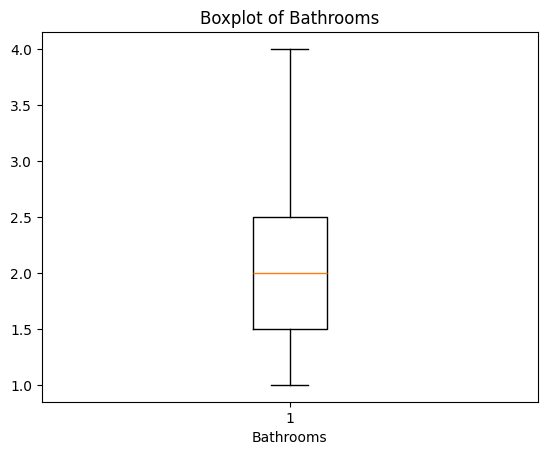

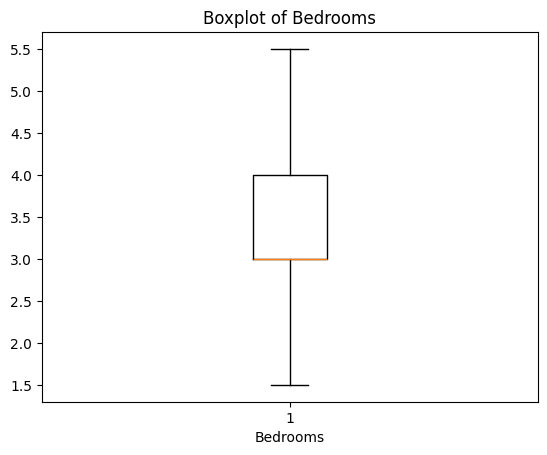

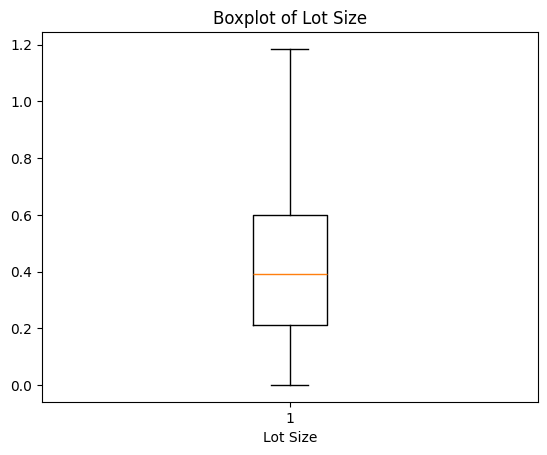

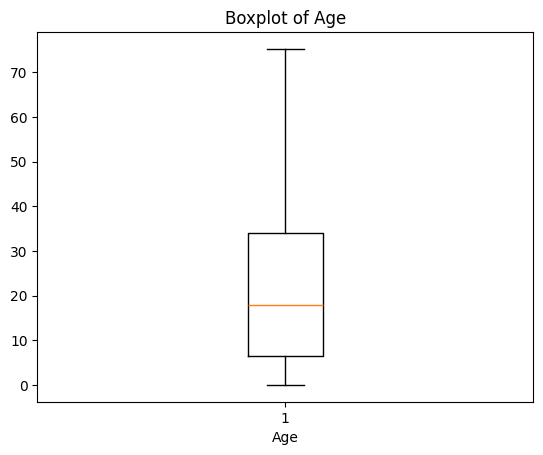

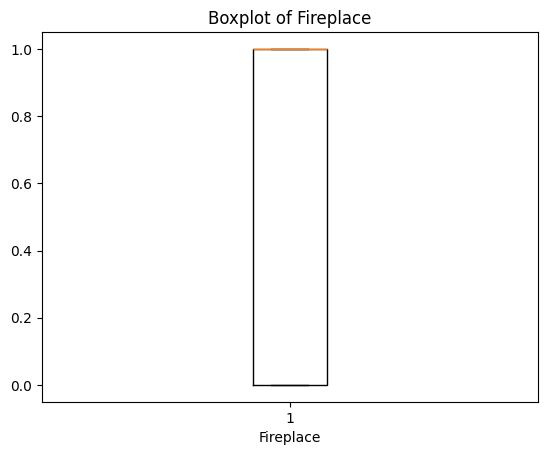

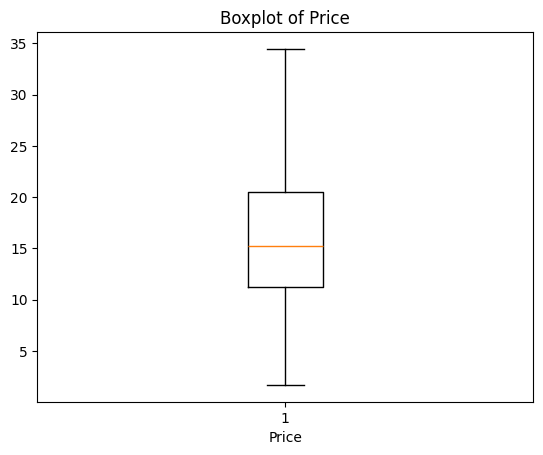

In [20]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [21]:
df.head()

,Living Area,Bathrooms,Bedrooms,Lot Size,Age,Fireplace,Price
0,1.982,1.0,3.0,1.185,75.25,0,14.2212
1,1.676,1.5,3.0,0.380,14.00,1,13.4865
2,1.694,2.0,3.0,0.960,15.00,1,11.8007
3,1.800,1.0,2.0,0.480,49.00,1,13.8297
4,2.088,1.0,3.0,1.185,29.00,1,12.9470


In [24]:
df.dtypes

,0
Living Area,float64
Bathrooms,float64
Bedrooms,float64
Lot Size,float64
Age,float64
Fireplace,int64
Price,float64


In [27]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.6908805408165515
MAE: 2.4411574358618653


In [33]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 0.6397113861315249
Test Score: 0.6908805408165515


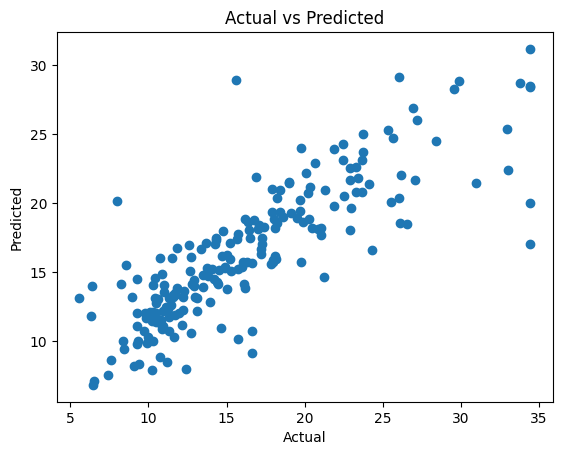

In [34]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [35]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))

R2 Score: 0.6800278973070506
MAE: 2.480655218670076


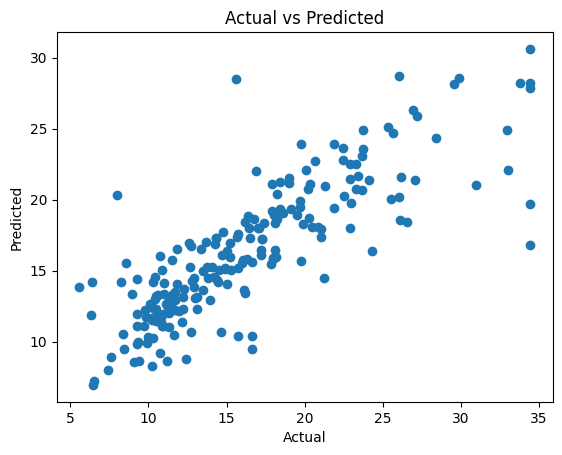

In [36]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [37]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))

R2 Score: 0.6908604367671272
MAE: 2.4412824364903787


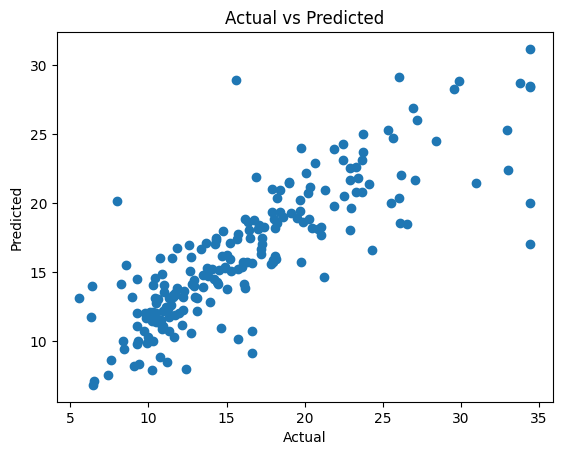

In [38]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [39]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha = 0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_elastic))
print("MAE:", mean_absolute_error(y_test, y_pred_elastic))

R2 Score: 0.6804057870049294
MAE: 2.499901908660956


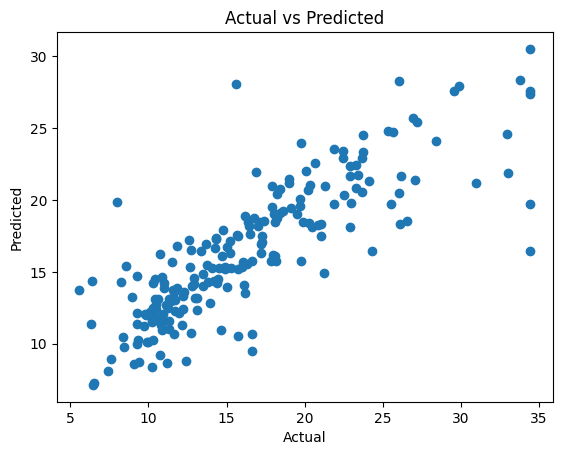

In [40]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_elastic)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()